In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=0
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"


In [3]:
filename= f"channel_metrics_by_network_{identifier}.csv"
results_df= pd.read_csv(os.path.join(metrics_dir, filename))
print(f"Results loaded from {os.path.join(metrics_dir, filename)}")
print(results_df.head())

Results loaded from c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\snnTorch\eval\live_results\metrics\channel_metrics_by_network_30000_1000_100.csv
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  215  786   9   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  203  480  21   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  183  259  41   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  146  112  78   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  142  178  82   

   Precision    Recall        F1  
0   0.214785  0.959821  0.351020  
1   0.297218  0.906250  0.447630  
2   0.414027  0.816964  0.549550  
3   0.565891  0.651786  0.605809  
4   0.443750  0.633929  0.522059  


In [4]:
def plot_whisker_datasets_general(metrics_df):
    # Add "Overall" group (all datasets combined)
    overall_df = metrics_df.copy()
    overall_df["Dataset"] = "Overall"
    full_df = pd.concat([metrics_df, overall_df])

    metrics = ["Precision", "Recall", "F1"]
    datasets = sorted(full_df["Dataset"].unique())
    colors = ["royalblue", "seagreen", "darkorange"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    fig.suptitle("Per-Dataset Metric Distributions (All Channels)", fontsize=16)

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        data_to_plot = [full_df[full_df["Dataset"] == dataset][metric].dropna().values for dataset in datasets]
        
        bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.6)

        for patch in bp['boxes']:
            patch.set_facecolor(colors[idx])
            patch.set_alpha(0.6)
        for whisker in bp['whiskers']:
            whisker.set_color(colors[idx])
        for cap in bp['caps']:
            cap.set_color(colors[idx])
        for median in bp['medians']:
            median.set_color("black")
            median.set_linewidth(2)

        ax.set_title(metric, fontsize=14)
        ax.set_xticks(range(1, len(datasets) + 1))
        ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Score", fontsize=12) if idx == 0 else None
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


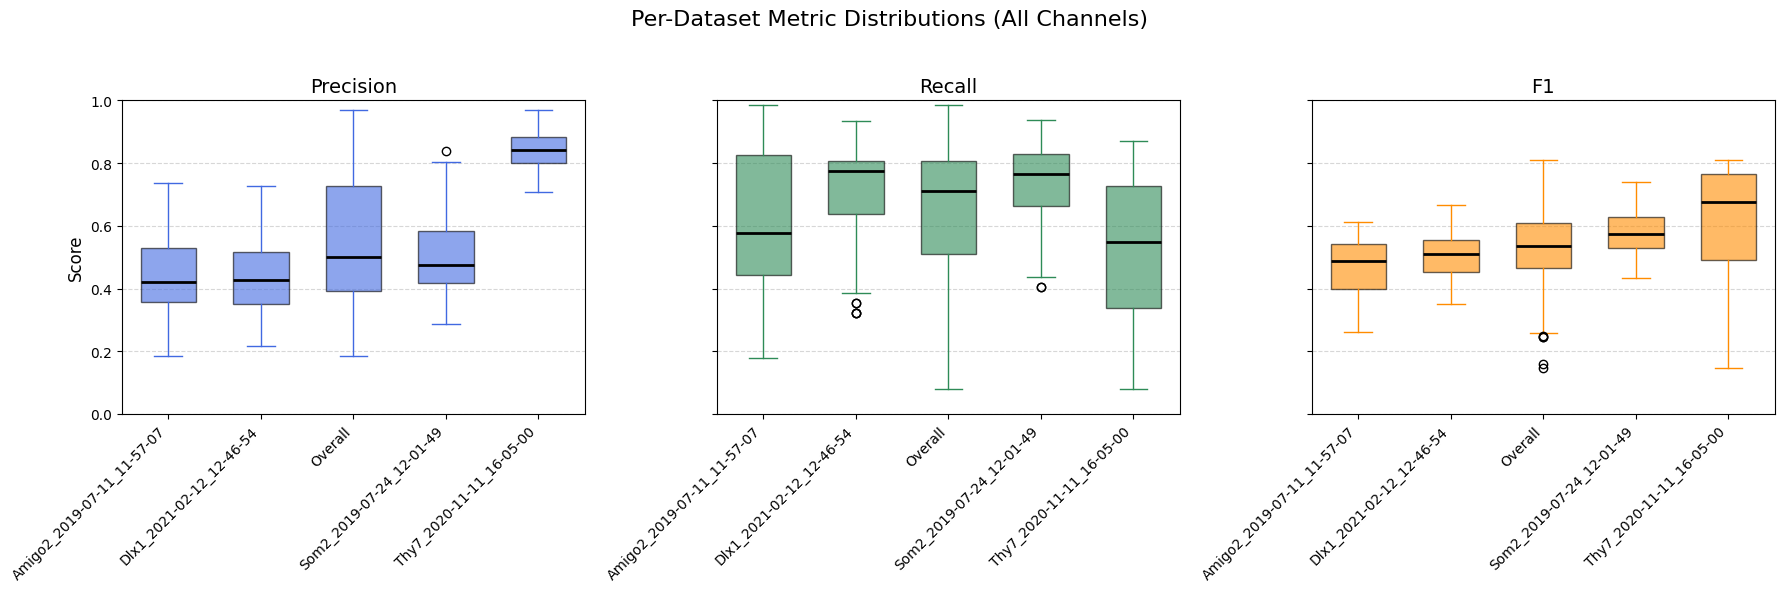

: 

In [ ]:
plot_whisker_datasets_general(results_df)